### Task 8 - final pipeline:

imports

In [2]:
import sys
import shutil
import cv2
import numpy as np
import pandas as pd
from patchify import patchify, unpatchify
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, remove_small_objects
from skan import Skeleton, summarize
from skan.csr import skeleton_to_csgraph
import networkx as nx
import os
import re

Functions 

In [ ]:
# Function to crop the Petri dish (ROI) using the new crop routine
def petri_dish_crop(image_path):
    # Reading the given image from the file path (in grayscale)
    img = cv2.imread(image_path, 0)

    # Applying blur using GaussianBlur
    blur = cv2.GaussianBlur(img, (3, 3), 0)

    # Applying thresholding using OTSU thresholding
    _, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Applying morphological operations to clean up noise:
    # Dilation to connect fragmented parts followed by erosion to remove small noise
    kernel = np.ones((7, 7), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=3)
    thresh = cv2.erode(thresh, kernel, iterations=4)

    # Finding contours in the thresholded image
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Select the largest contour (assumed to be the petri dish)
    contour = max(contours, key=cv2.contourArea)

    # Getting the bounding rectangle of the contour for cropping
    x, y, w, h = cv2.boundingRect(contour)

    # Cropping the petri dish from the image
    crop = img[y : y + h, x : x + w]

    return crop



def padder(image, patch_size):

    """

    Adds padding to an image to make its dimensions divisible by a specified patch size.


    This function calculates the amount of padding needed for both the height and width of an image so that its dimensions become divisible by the given patch size. The padding is applied evenly to both sides of each dimension (top and bottom for height, left and right for width). If the padding amount is odd, one extra pixel is added to the bottom or right side. The padding color is set to black (0, 0, 0).


    Parameters:

    - image (numpy.ndarray): The input image as a NumPy array. Expected shape is (height, width, channels).

    - patch_size (int): The patch size to which the image dimensions should be divisible. It's applied to both height and width.


    Returns:

    - numpy.ndarray: The padded image as a NumPy array with the same number of channels as the input. Its dimensions are adjusted to be divisible by the specified patch size.


    Example:

    - padded_image = padder(cv2.imread('example.jpg'), 128)


    """

    h = image.shape[0]

    w = image.shape[1]

    height_padding = ((h // patch_size) + 1) * patch_size - h

    width_padding = ((w // patch_size) + 1) * patch_size - w


    top_padding = int(height_padding/2)

    bottom_padding = height_padding - top_padding


    left_padding = int(width_padding/2)

    right_padding = width_padding - left_padding


    padded_image = cv2.copyMakeBorder(image, top_padding, bottom_padding, left_padding, right_padding, cv2.BORDER_CONSTANT, value=0)

    return padded_image


def f1(y_true, y_pred):

    def recall_m(y_true, y_pred):

        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))

        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))

        recall = TP / (Positives+K.epsilon())
        return recall
    

    def precision_m(y_true, y_pred):

        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))

        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))

        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    

    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    

    return 2*((precision*recall)/(precision+recall+K.epsilon()))


def segment_image(prediction, extension_threshold=5, max_extension=100):

    """

    Segments an image into 5 parts and extends segments to capture full root systems.

    Works with both 2D and 3D arrays.
    

    Args:

        prediction: numpy array of shape (height, width) or (height, width, channels)

        extension_threshold: minimum number of pixels to trigger extension

        max_extension: maximum number of pixels to extend in either direction
        

    Returns:

        list: List of numpy arrays, each representing a segment of the original image

    """

    # Handle both 2D and 3D arrays

    if len(prediction.shape) == 2:

        h, w = prediction.shape

        is_2d = True

    else:

        h, w, c = prediction.shape

        is_2d = False
        

    base_segment_width = w // 5
    

    # Initialize boundaries

    boundaries = []

    extended_segments = []
    

    # First pass: get initial segments and detect extensions needed

    for i in range(5):

        start = i * base_segment_width

        end = (i + 1) * base_segment_width if i < 4 else w
        

        # Check if roots extend beyond the base segment

        segment = prediction[:, start:end] if is_2d else prediction[:, start:end, :]

        extended_left = 0

        extended_right = 0
        

        if i > 0:  # Check left extension (except for first segment)

            for ext in range(1, max_extension + 1):

                if start - ext < 0:

                    break

                left_column = prediction[:, start - ext] if is_2d else prediction[:, start - ext, :].max(axis=1)

                if np.count_nonzero(left_column) > extension_threshold:

                    extended_left = ext

                else:

                    break
                    

        if i < 4:  # Check right extension (except for last segment)

            for ext in range(1, max_extension + 1):

                if end + ext >= w:

                    break

                right_column = prediction[:, end + ext] if is_2d else prediction[:, end + ext, :].max(axis=1)

                if np.count_nonzero(right_column) > extension_threshold:

                    extended_right = ext

                else:

                    break
        

        # Store the extended boundaries

        actual_start = max(0, start - extended_left)

        actual_end = min(w, end + extended_right)

        boundaries.append((actual_start, actual_end))
        

        # Ensure the segment is a numpy array

        segment = prediction[:, actual_start:actual_end] if is_2d else prediction[:, actual_start:actual_end, :]

        extended_segments.append(np.array(segment))
    

    # # Display the results

    # fig, axes = plt.subplots(1, 5, figsize=(15, 5))

    # for ax, segment in zip(axes, extended_segments):

    #     ax.imshow(segment, cmap='gray' if is_2d else None)

    #     ax.axis('off')

    # plt.tight_layout()

    # plt.show()
    

    # Return the list of numpy arrays

    return extended_segments


def find_longest_path(graph):

    """Finds the longest path in a graph."""

    longest_path = []

    for start_node in graph.nodes():

        for end_node in graph.nodes():

            try:

                path = nx.shortest_path(graph, source=start_node, target=end_node)

                if len(path) > len(longest_path):
                    longest_path = path

            except nx.NetworkXNoPath:

                pass  # No path between these nodes
    return longest_path


def measuring_skeleton(individual_plant):

    # For some reason the image is rotated clockwise 90 degrees

    plant_contiguous = np.ascontiguousarray(individual_plant)


    root = skeletonize(plant_contiguous)

    root_skeleton = Skeleton(root)

    summary = summarize(root_skeleton)


    # Create a graph from the summary

    G = nx.from_pandas_edgelist(summary, source='node-id-src', target='node-id-dst', edge_attr='branch-distance')


    # Get the connected components

    components = list(nx.connected_components(G))


    # Changed logic for largest component.

    longest_path_component = None

    longest_path_length = 0

    for component in components:

        subgraph = G.subgraph(component)

        path = find_longest_path(subgraph)

        if len(path) > longest_path_length:
            longest_path_length = len(path)

            longest_path_component = subgraph


    # Now you have the largest component based on path length

    largest_subgraph = longest_path_component


    # Use the actual image coordinates

    pos = {}

    for _, row in summary.iterrows():

        if row['node-id-src'] not in pos:

            pos[row['node-id-src']] = (row['image-coord-src-0'], row['image-coord-src-1'])

        if row['node-id-dst'] not in pos:

            pos[row['node-id-dst']] = (row['image-coord-dst-0'], row['image-coord-dst-1'])


    # Find start and end nodes

    start_node = min(largest_subgraph, key=lambda node: pos[node][0])

    end_node = max(largest_subgraph, key=lambda node: pos[node][0])


    # Calculate path using Dijkstra's algorithm

    path_length = nx.dijkstra_path_length(largest_subgraph, start_node, end_node, weight='branch-distance')


    # Get the path

    path = nx.dijkstra_path(largest_subgraph, start_node, end_node, weight='branch-distance')


    # Visualization

    plt.figure(figsize=(10, 10))

    plt.imshow(root, cmap='gray')


    # Plot all nodes

    for node in largest_subgraph.nodes():

        plt.plot(pos[node][0], pos[node][1], 'b.', markersize=5)


    path_coords = []

    for i in range(len(path)-1):

        node1, node2 = path[i], path[i+1]

        x1, y1 = pos[node1]

        x2, y2 = pos[node2]

        plt.plot([x1, x2], [y1, y2], 'r-', linewidth=2, alpha=0.5)

        path_coords.extend([(x1, y1), (x2, y2)])


    # Plot start and end nodes

    plt.plot(pos[start_node][0], pos[start_node][1], 'g*', markersize=15, label='Start Node')

    plt.plot(pos[end_node][0], pos[end_node][1], 'r*', markersize=15, label='End Node')

    print(f"Path length: {path_length}")
    return path_length



def natural_key(string):

    # Split into a list of integers and strings: 'test_10.tif' → ['test_', 10, '.tif']

    return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", string)]

Final Pipeline:

Processing image: kaggle\test_image_1.tif
4/4 [==============================] - 17s 2s/step


C:\Users\victo\AppData\Local\Temp\ipykernel_22964\4178779824.py:290: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(root_skeleton)


Path length: 591.8355697996833


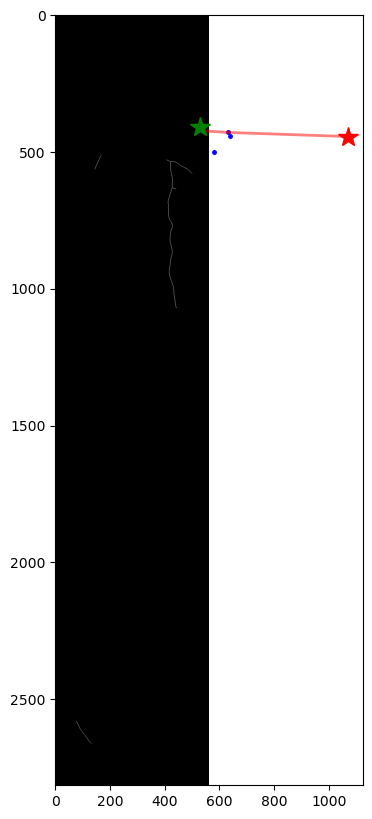

Path length: 543.2964645562821


C:\Users\victo\AppData\Local\Temp\ipykernel_22964\4178779824.py:290: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(root_skeleton)


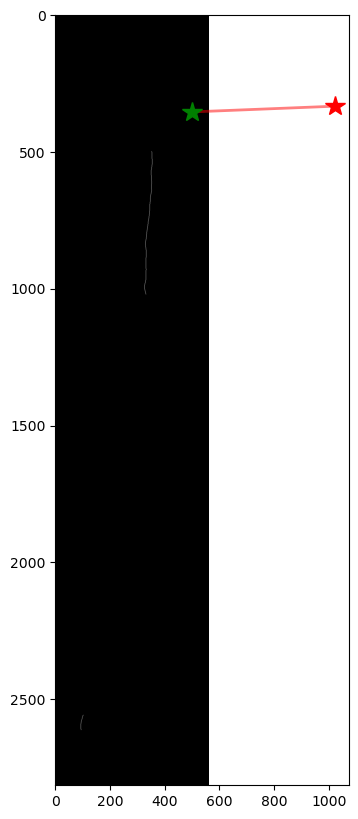

Path length: 688.1025971044426


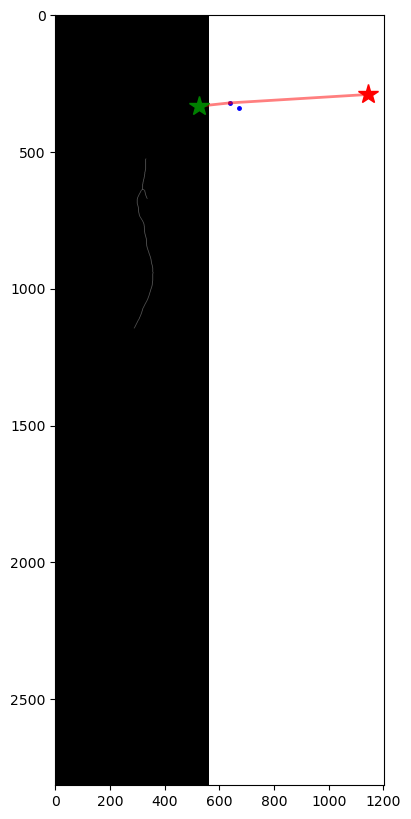

Path length: 442.8822509939089


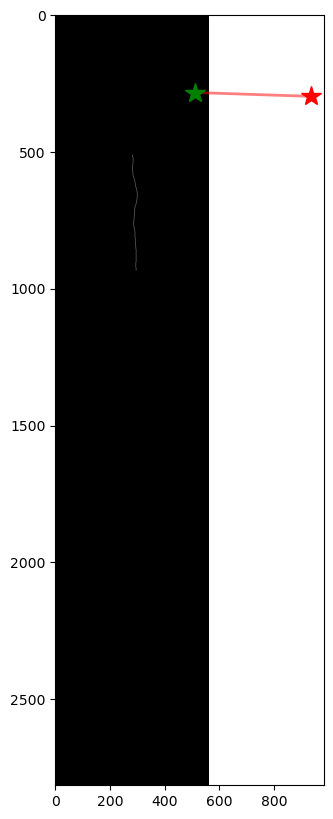

Path length: 665.8772003600259


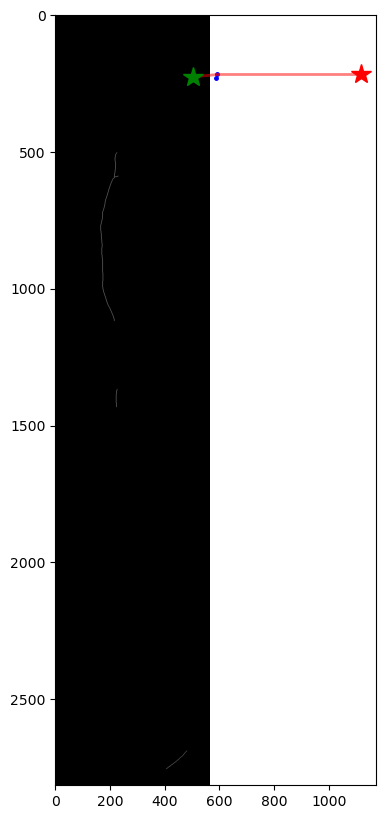

Processing image: kaggle\test_image_2.tif
4/4 [==============================] - 1s 322ms/step
Path length: 991.7594513539337


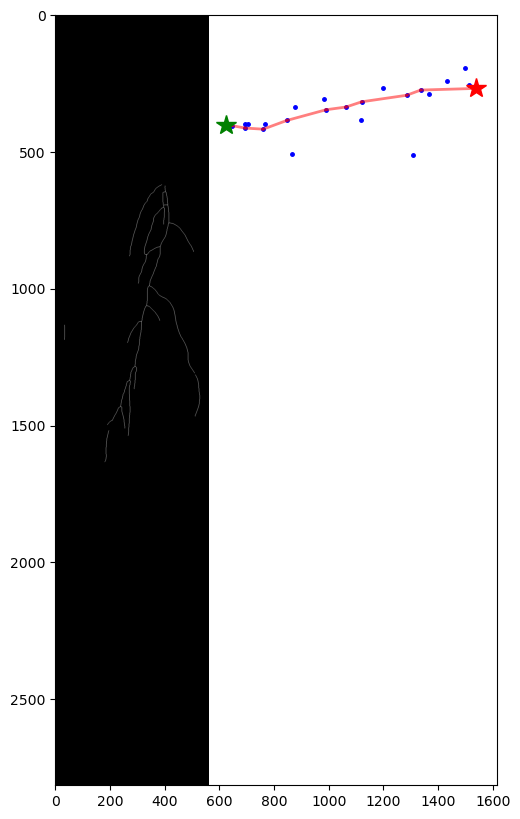

Path length: 1648.5605332682132


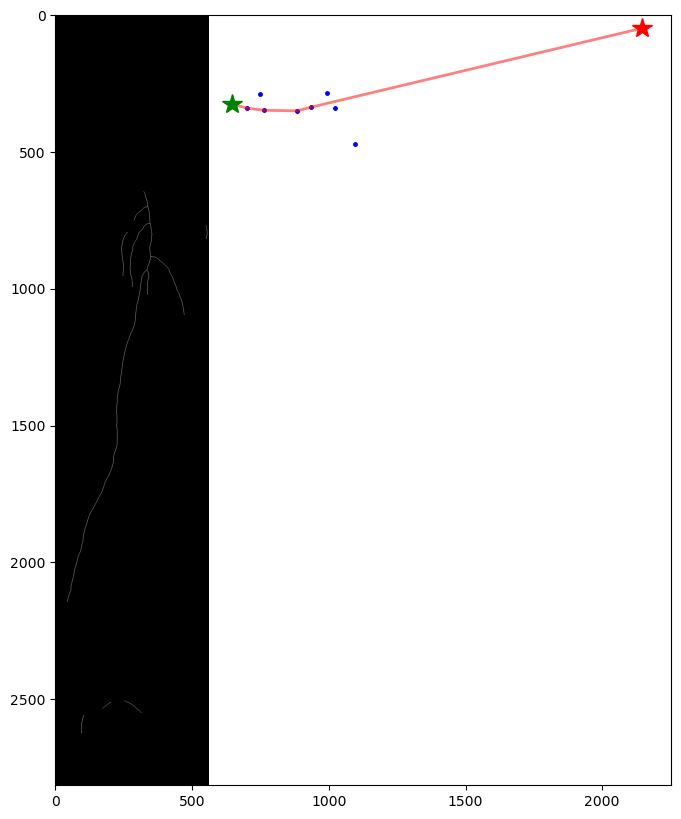

Path length: 1258.4457428549495


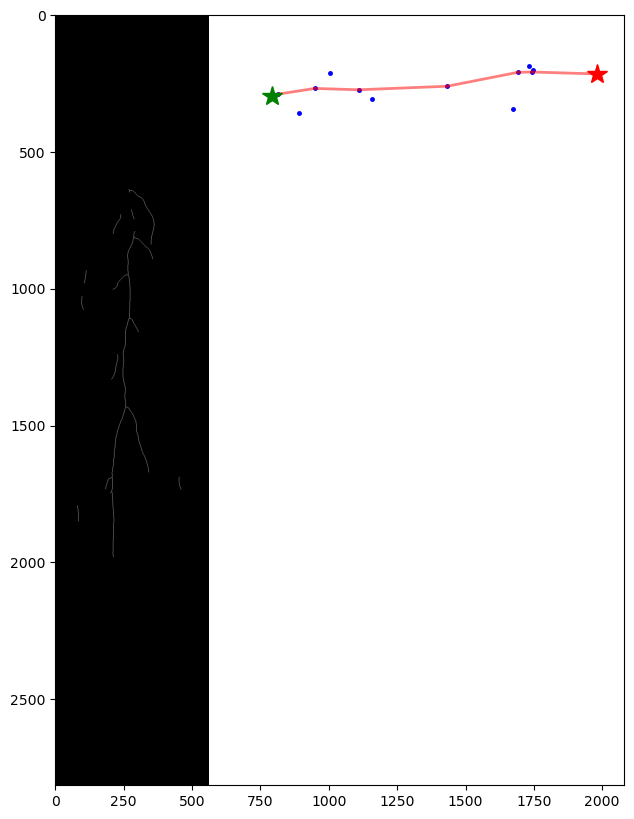

Path length: 1308.9726547895316


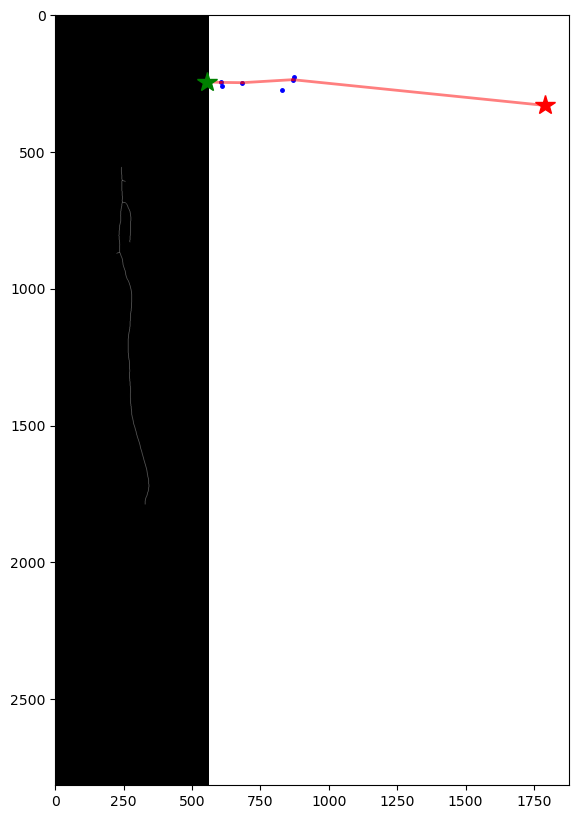

Path length: 1117.4457428549492


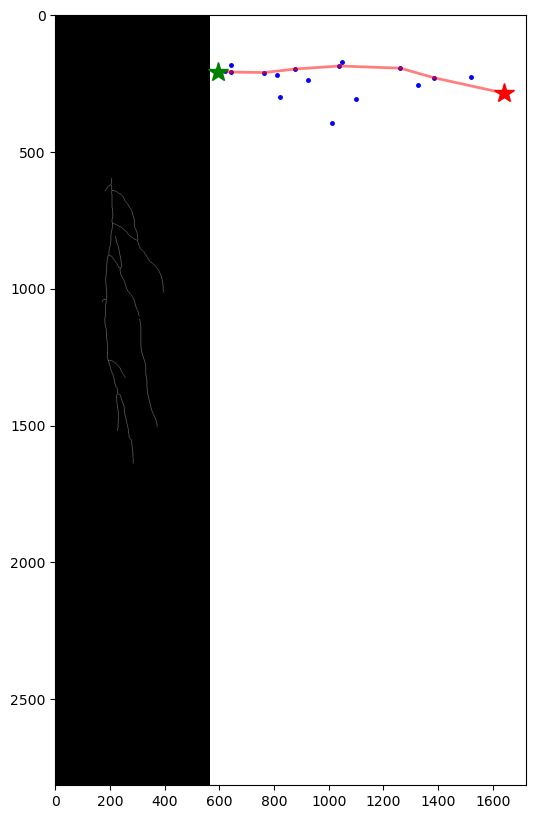

Processing image: kaggle\test_image_3.tif
4/4 [==============================] - 1s 163ms/step
Path length: 781.4457428549505


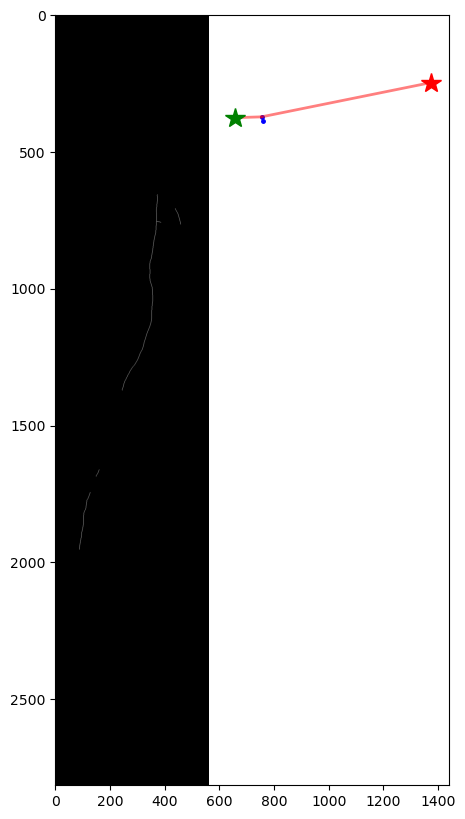

Path length: 1412.511760032933


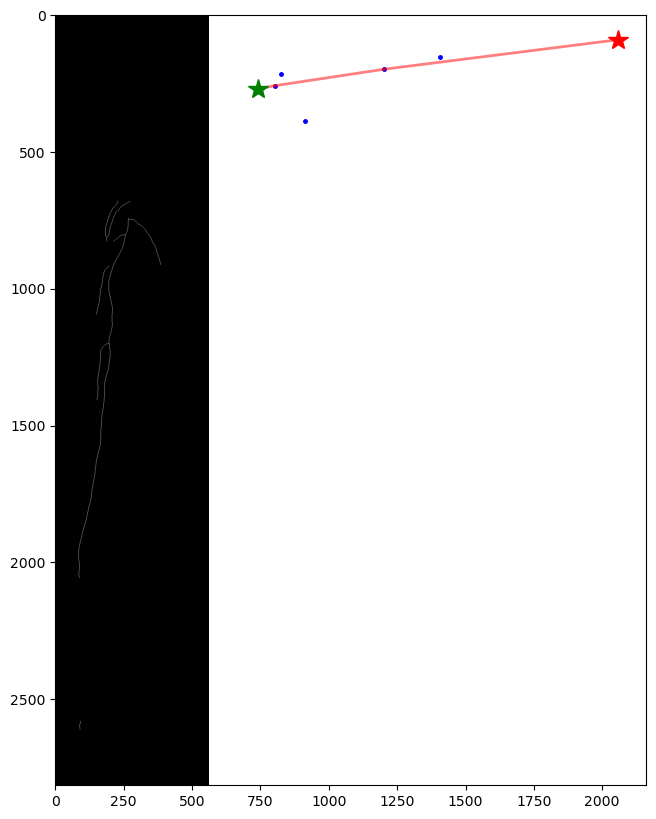

Path length: 1460.4112549695449


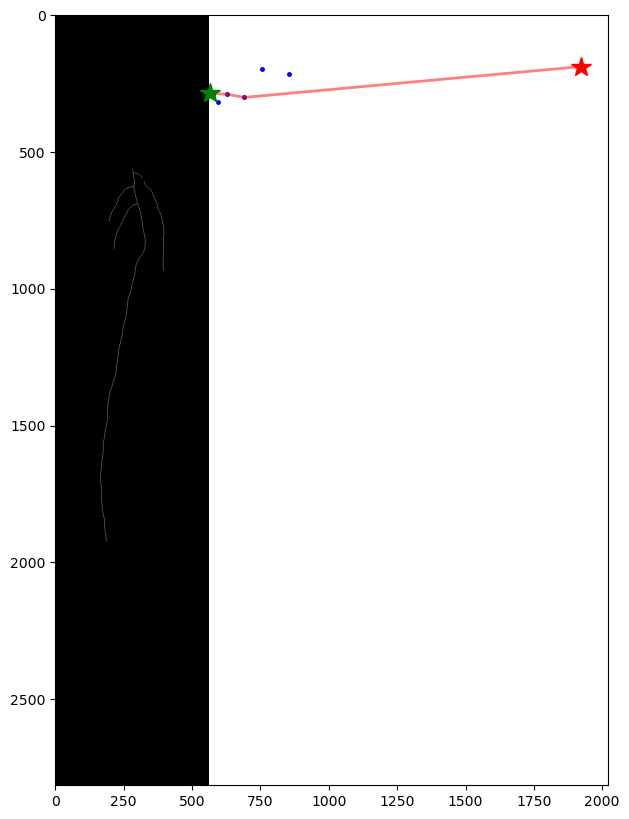

Path length: 1548.7838379715752


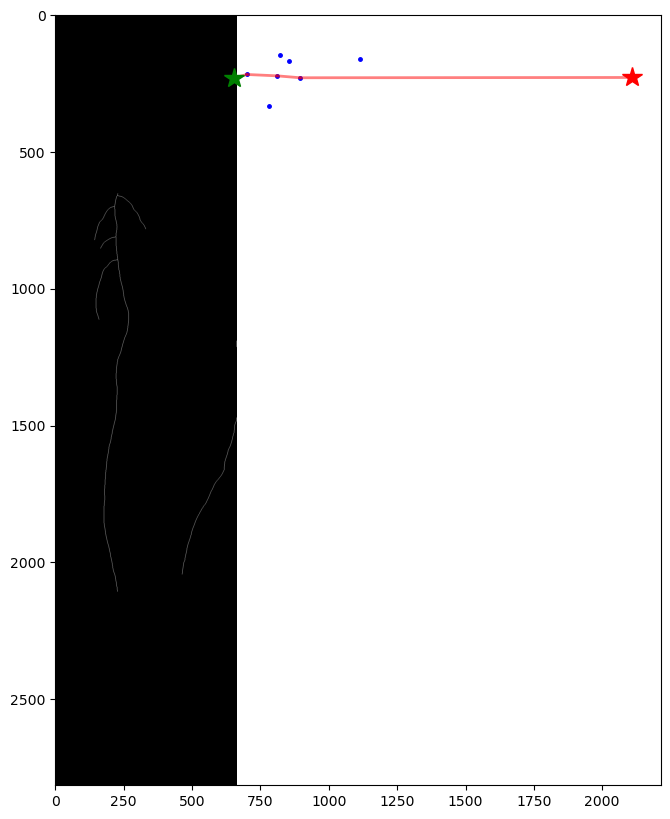

Path length: 1534.0752518939746


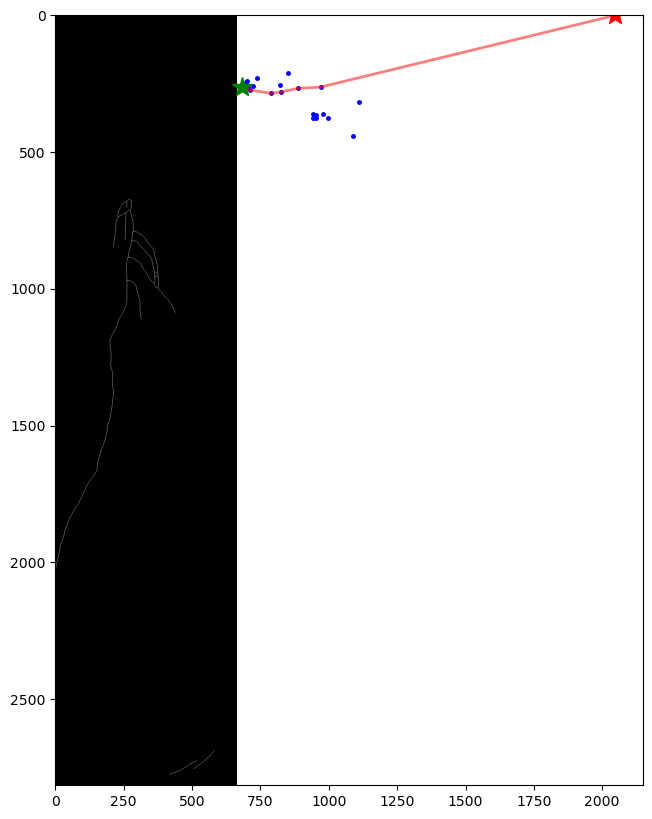

Processing image: kaggle\test_image_4.tif
4/4 [==============================] - 1s 212ms/step
Path length: 1002.7594513539351


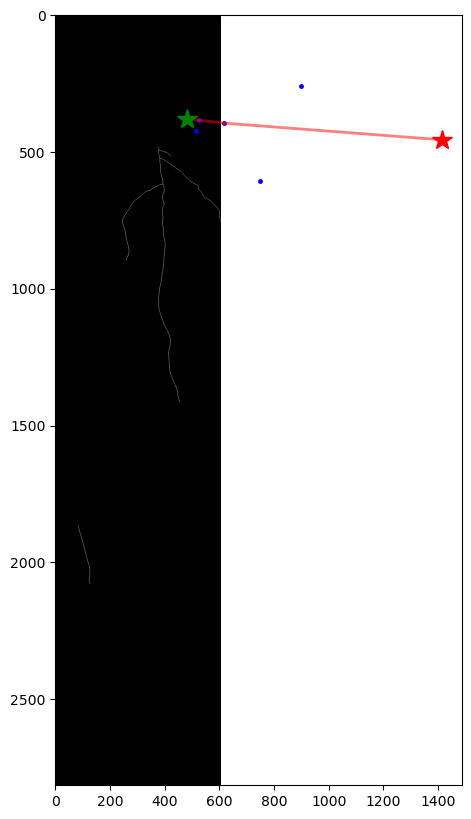

Path length: 1148.6000717875004


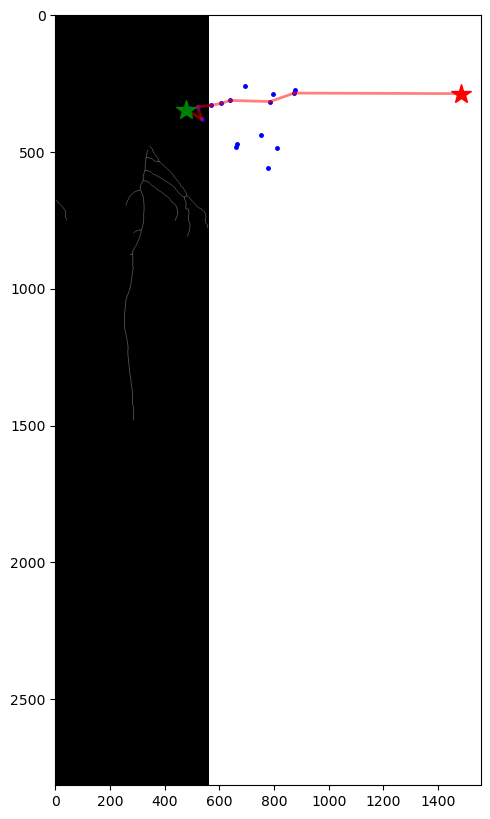

Path length: 942.6467529817266


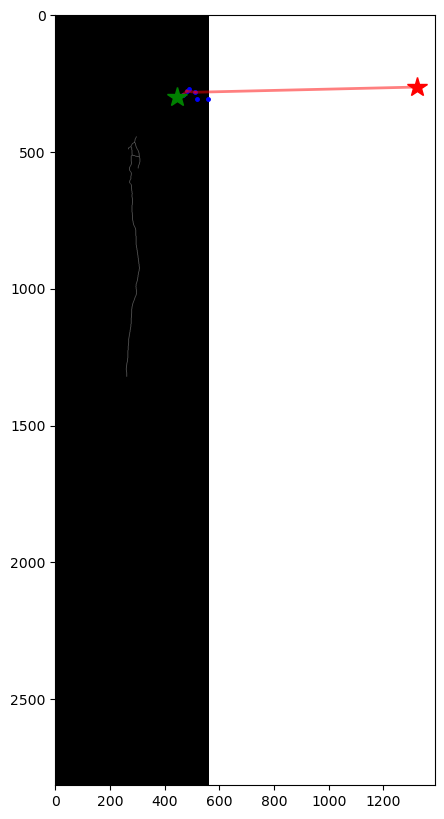

Path length: 1021.2863632885168


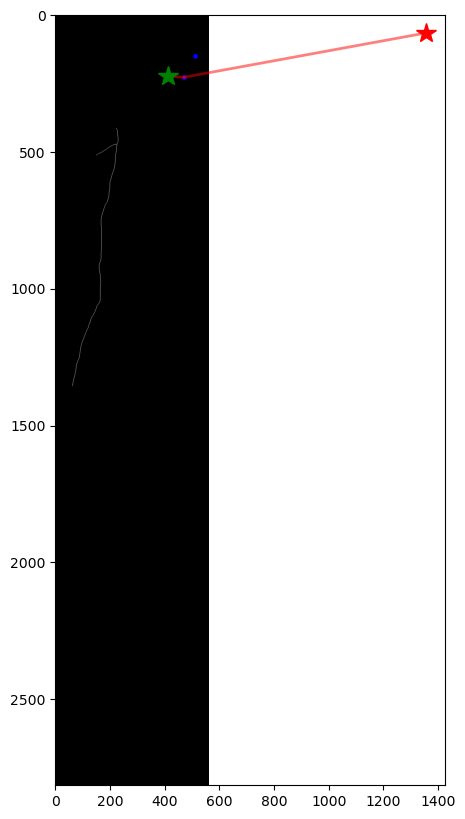

Path length: 990.9604614807115


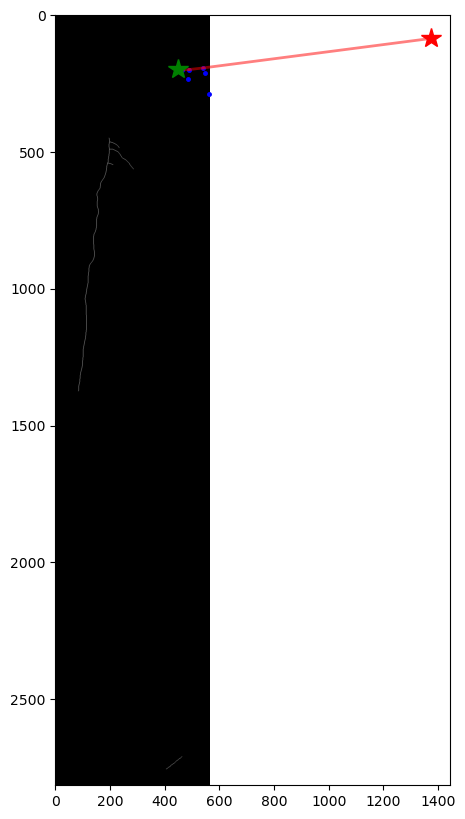

Processing image: kaggle\test_image_5.tif
4/4 [==============================] - 1s 172ms/step
Path length: 1319.5411972844552


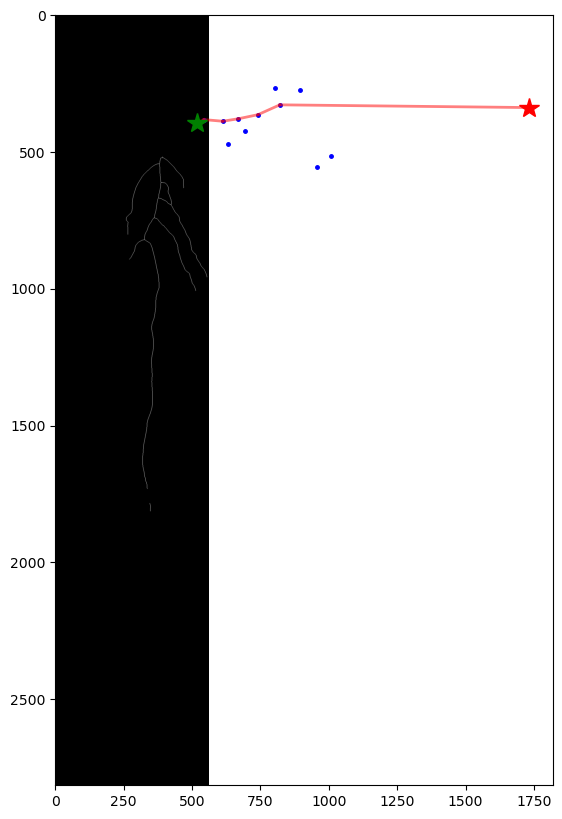

Path length: 1186.9482681718914


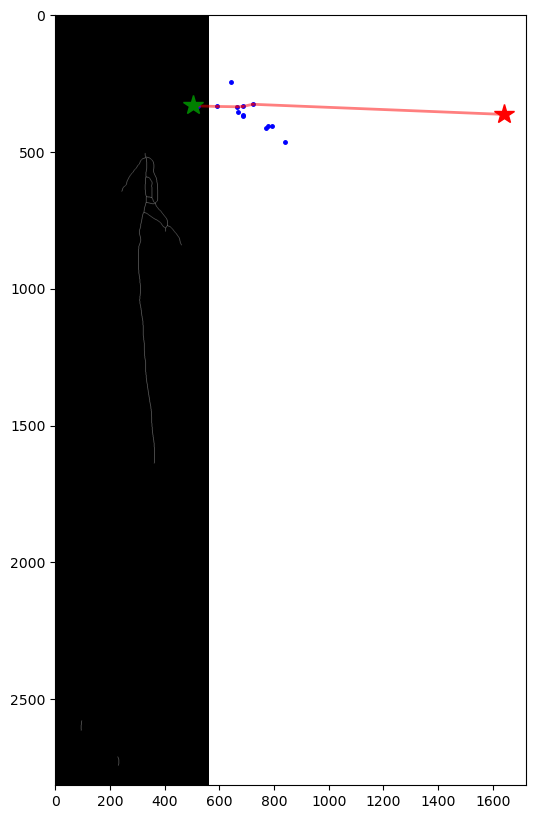

Path length: 1134.9137802864864


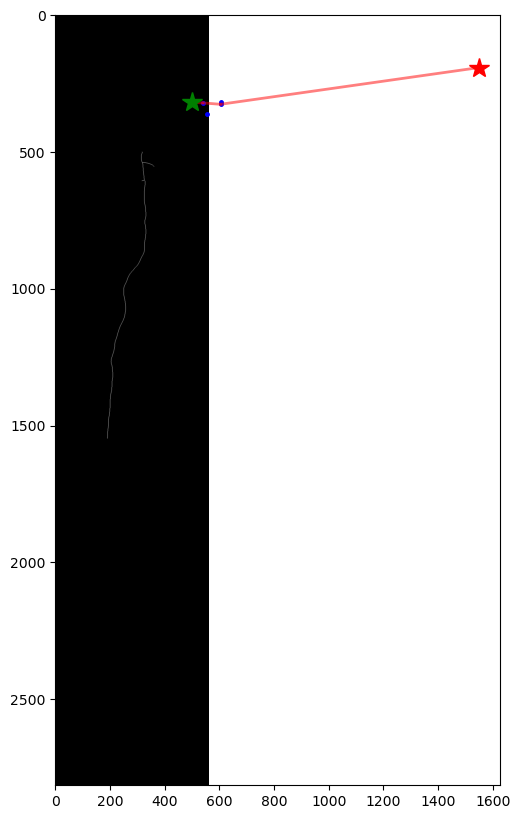

Path length: 1353.2152954766505


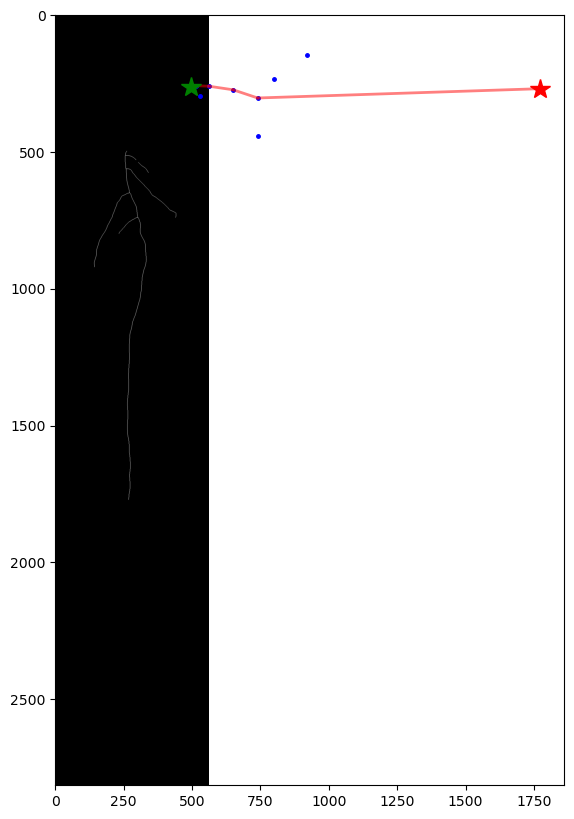

Path length: 1518.3990616607239


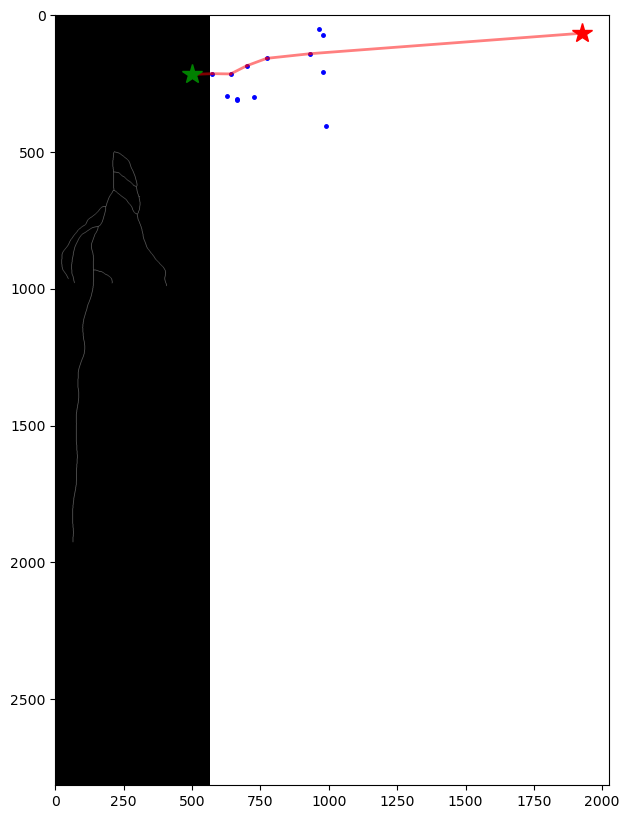

Processing image: kaggle\test_image_6.tif
4/4 [==============================] - 1s 201ms/step
Path length: 47.38477631085023


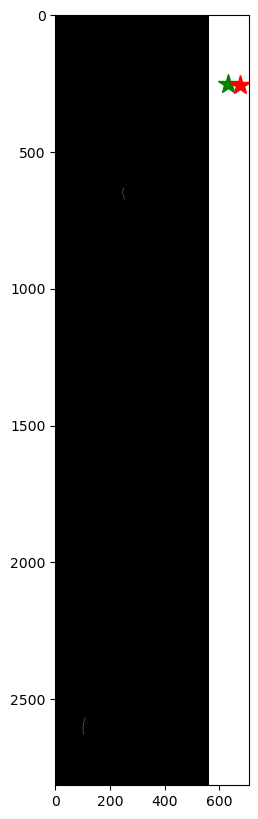

Processing image: kaggle\test_image_7.tif
4/4 [==============================] - 1s 149ms/step
Path length: 135.254833995939


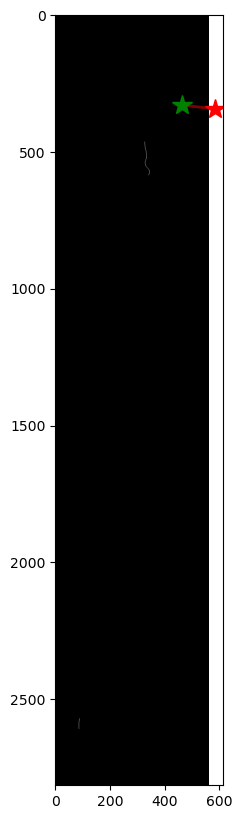

Path length: 138.3553390593274


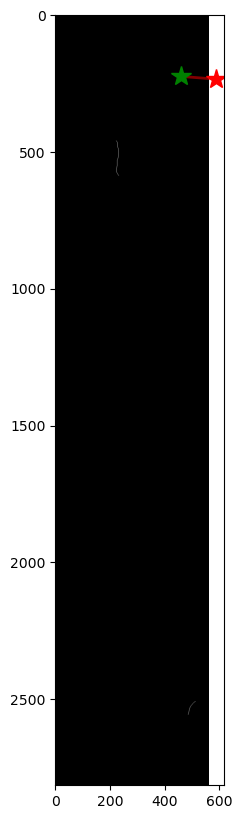

Path length: 48.52691193458118


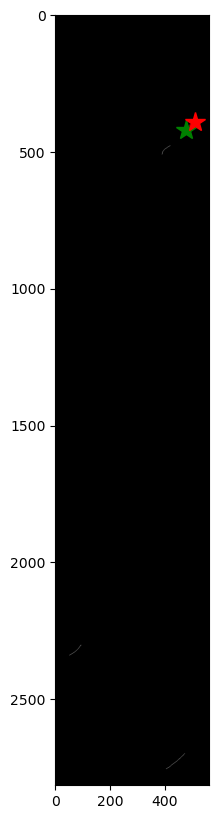

Processing image: kaggle\test_image_8.tif
4/4 [==============================] - 1s 190ms/step
Path length: 299.8822509939089


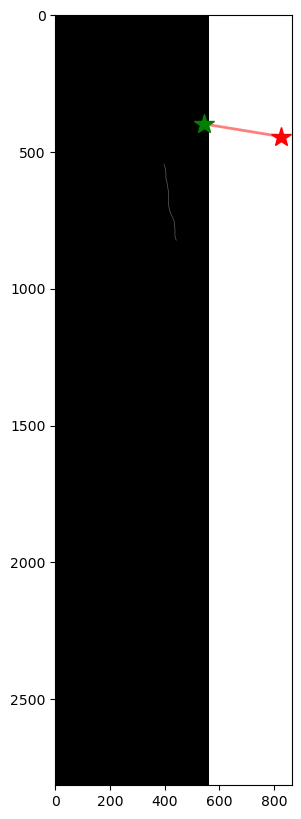

Path length: 283.8406204335661


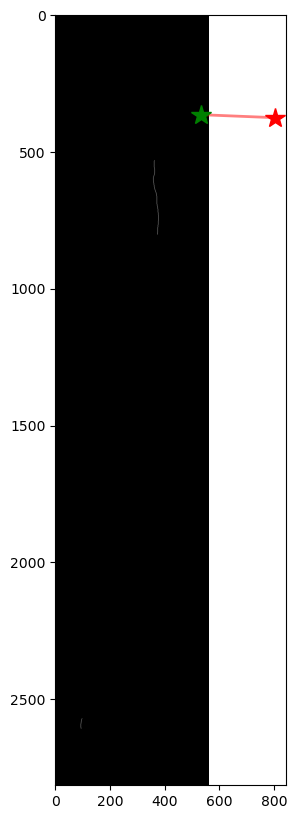

Path length: 346.3380951166248


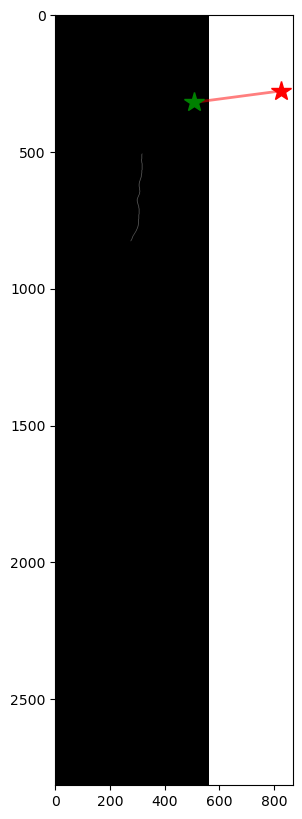

Path length: 340.98275605729725


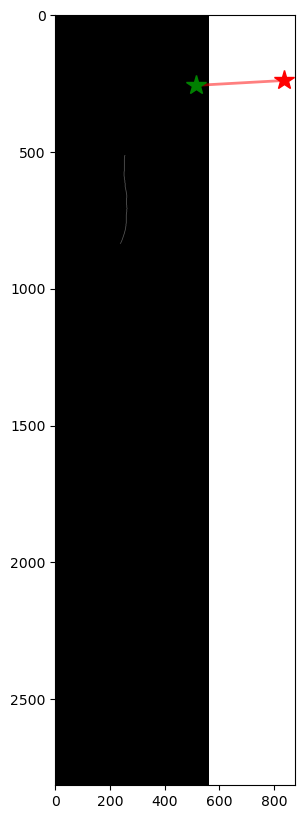

Path length: 280.05382386916267


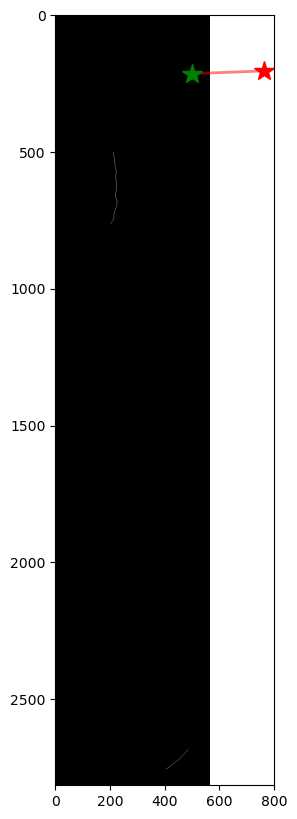

Processing image: kaggle\test_image_9.tif
4/4 [==============================] - 1s 134ms/step
Path length: 415.693434175952


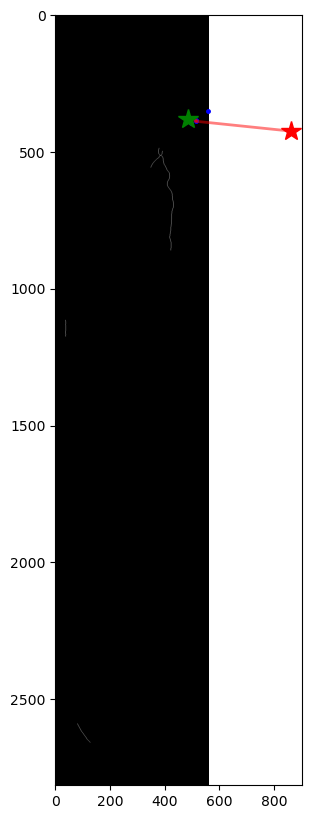

Path length: 403.55129855222094


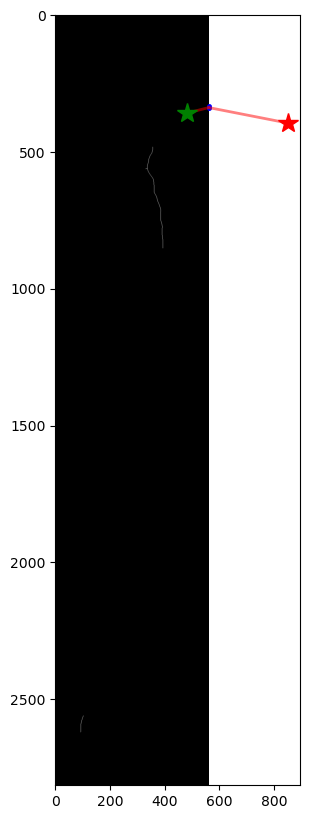

Path length: 451.63455967290633


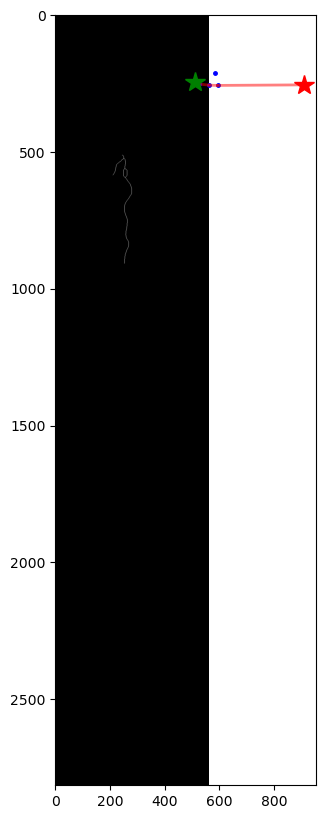

Path length: 401.4091629284903


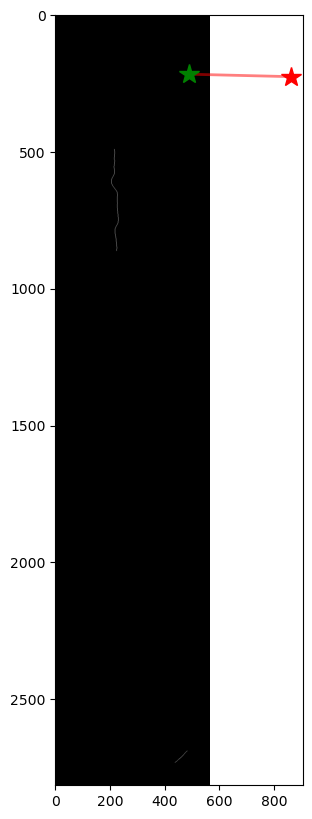

Processing image: kaggle\test_image_10.tif
4/4 [==============================] - 1s 178ms/step
Path length: 646.9898987322346


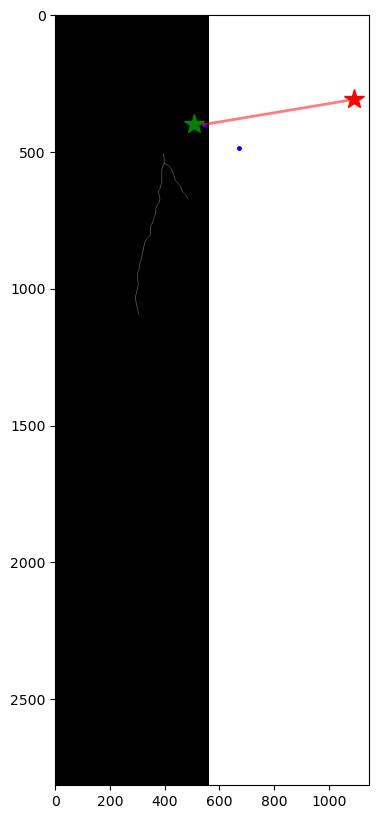

Path length: 704.5046173579958


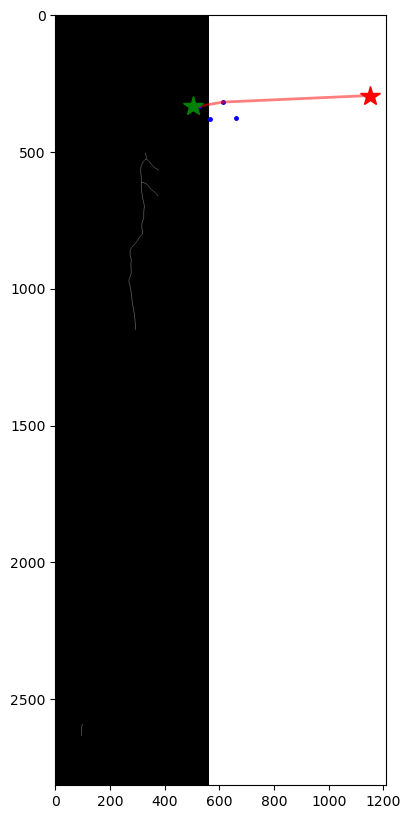

Path length: 765.7350647362944


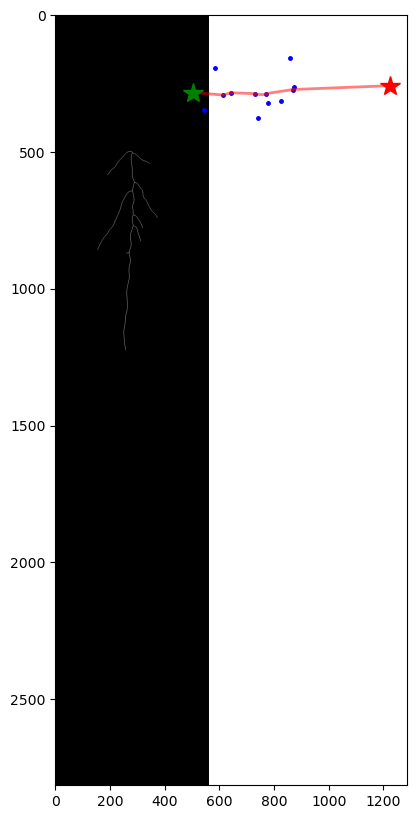

Path length: 821.286363288516


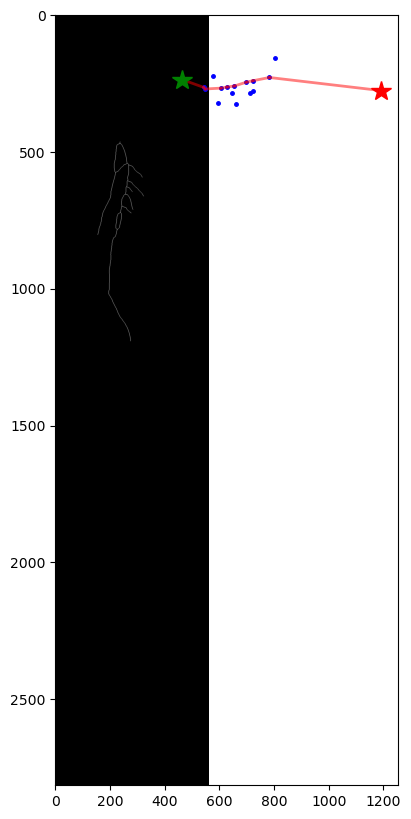

Path length: 773.2741699796958


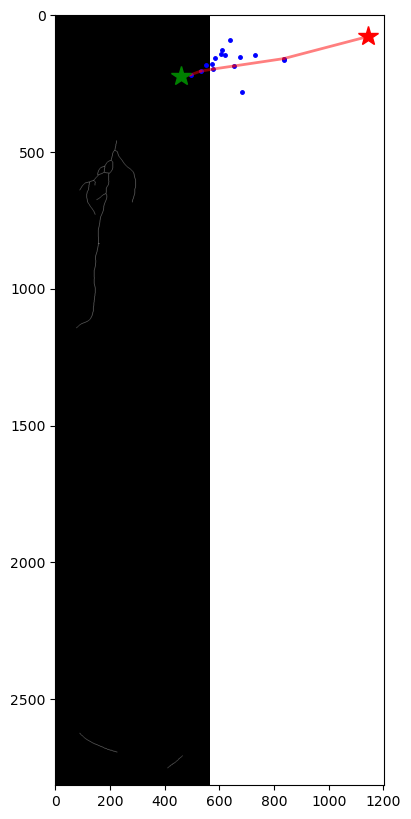

Processing image: kaggle\test_image_11.tif
4/4 [==============================] - 1s 213ms/step
Path length: 616.0020920410532


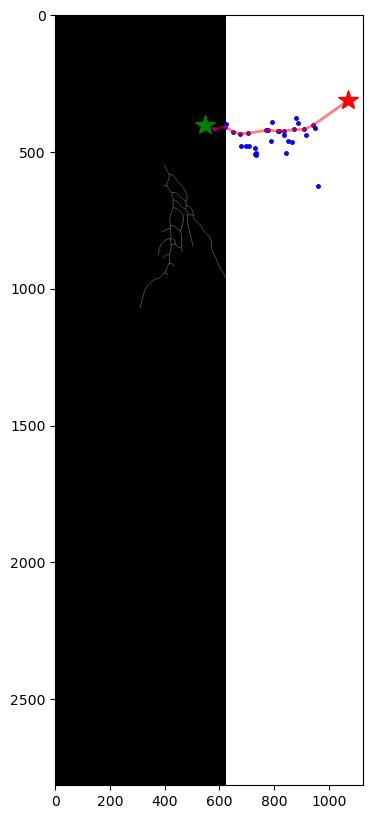

Path length: 1160.796031280394


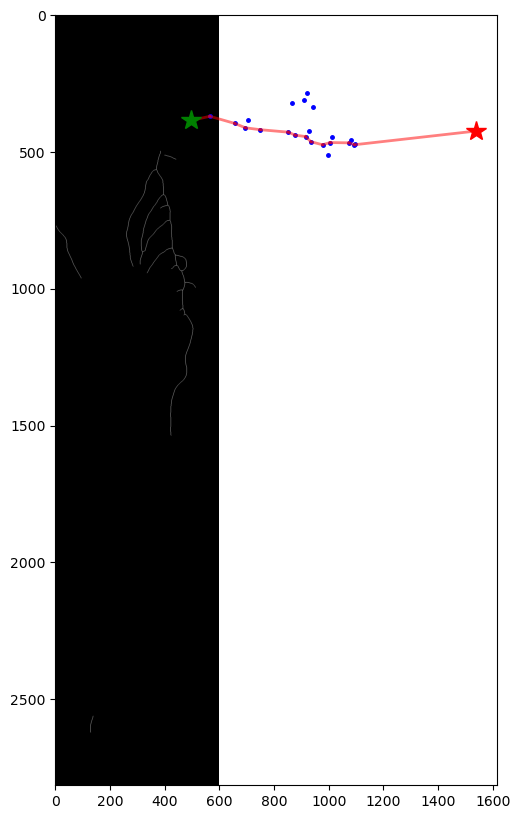

Path length: 1331.5706345359777


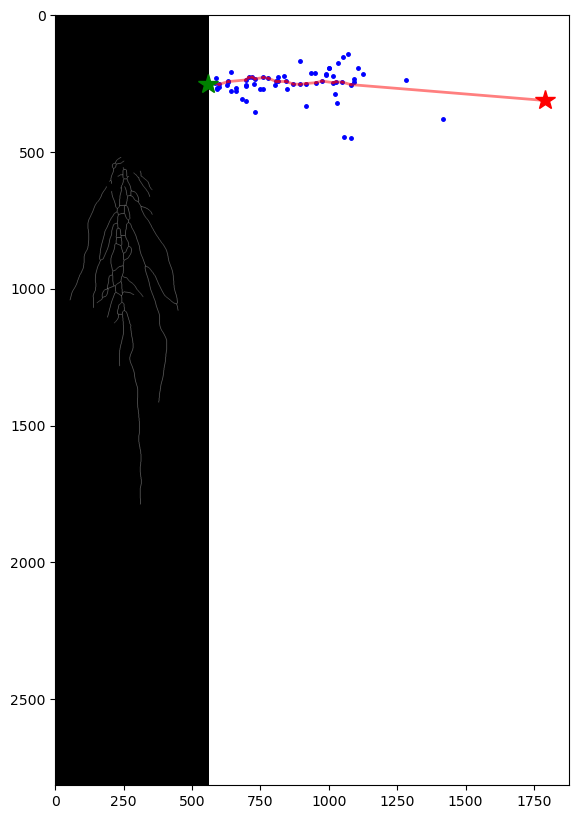

Path length: 1308.6366517139595


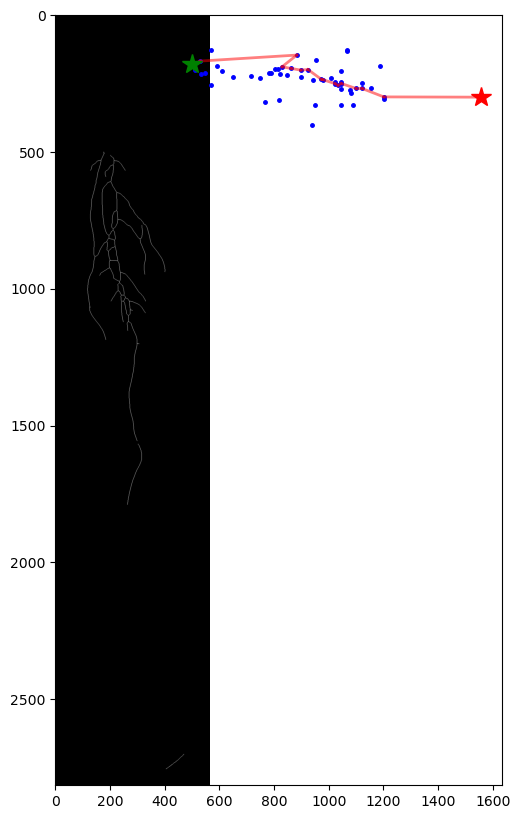

       Length (px)
count    55.000000
mean    715.188730
std     516.245897
min       0.000000
25%     291.861436
50%     688.102597
75%    1154.698052
max    1648.560533


In [ ]:
def pipeline(image_dir, patch_size=256):
    # Loading the trained model outside of the loop to save time
    model_path = "victoria_233182_Resnet_Model222_256px_iteration2.h5"
    model = load_model(model_path, custom_objects={"f1": f1})

    #list to store measurements for each plant
    measurements = list()

    # Processing each image file in the image directory
    for file in sorted(os.listdir(image_dir), key=natural_key):
        if file.endswith(".tif"):
            #Forming full file path for the image
            image_path = os.path.join(image_dir, file)
            print("Processing image:", image_path)

            ### IMAGE PREPROCESSING ###
            # Cropping the petri dish petri_dish_crop function
            image_cropped = petri_dish_crop(image_path)

            #Converting the cropped grayscale image to 3 channels (RGB) for model input
            #This is necessary because the model expects 3-channel input
            image_color = cv2.cvtColor(image_cropped, cv2.COLOR_GRAY2RGB)

            #Normalizing the image data by scaling pixel values to [0, 1]
            image_np = np.array(image_color) / 255.0

            #Padding the image so its dimensions are a multiple of patch_size
            image_padded = padder(image_np, patch_size=patch_size)

            #Dividing the padded image into patches
            patches = patchify(
                image_padded, (patch_size, patch_size, 3), step=patch_size
            )

            #Calculating expected shape based on the padded image dimensions
            expected_shape = (
                image_padded.shape[0] // patch_size,
                image_padded.shape[1] // patch_size,
            )

            #Reshaping patches to be passed into the model
            patches = patches.reshape(-1, patch_size, patch_size, 3)

            ### GETTING THE PREDICTION ###
            predicted_patches = model.predict(patches)

            #Reshaping the prediction patches back into the spatial structure of the original image
            #This step is necessary to reconstruct the full prediction image from the patches
            predicted_patches = predicted_patches.reshape(
                expected_shape[0],
                expected_shape[1],
                patch_size,
                patch_size,
                predicted_patches.shape[-1],
            )
            predicted_patches = predicted_patches[:, :, :, :, 0]

            #Reconstructing the full prediction image from patches using unpatchify
            #This step combines the patches back into a single image
            prediction = unpatchify(predicted_patches, image_padded.shape[:2])

            # Threshold the predictions to obtain a binary image  
            prediction_bool = prediction > 0.5
            prediction_clean = remove_small_objects(prediction_bool, min_size=100)

            #Converting cleaned prediction to uint8 for further OpenCV operations
            prediction_clean = prediction_clean.astype(np.uint8)

            # Applying dilation and erosion operations
            kernel = np.ones((3, 3), np.uint8)
            prediction_d = cv2.dilate(prediction_clean, kernel, iterations=4)
            prediction_closed = cv2.erode(prediction_d, kernel, iterations=4)

            # Creating a black strip above the image (300 pixels) to remove top noise
            prediction_closed[:300, :] = 0

            #Individual Root Prediction 
            individual_plants = segment_image(prediction_closed)

            #Measuring Each Individual Root
            for plant_index, plant in enumerate(individual_plants):
                custom_plant_index = (
                    f"{os.path.splitext(file)[0]}_plant_{plant_index + 1}"
                )
                plant = np.array(plant)

                # Checking if the plant image is empty using a region sum check
                if tf.reduce_sum(plant[200:800, :]) == 0:
                    measurements.append(
                        {"Plant ID": str(custom_plant_index), "Length (px)": 0.0}
                    )
                else:
                    length = measuring_skeleton(plant)
                    plt.show()
                    measurements.append(
                        {"Plant ID": str(custom_plant_index), "Length (px)": length}
                    )

    measurements_df = pd.DataFrame(measurements)
    measurements_df.set_index("Plant ID", inplace=True)
    # measurements_df.to_csv('submission_19_retake.csv', index=True)
    return measurements_df


#Running the pipeline on the 'kaggle' directory
df = pipeline("kaggle")
print(df.describe())

In [5]:
df = pd.read_csv('submission_19_retake.csv')
df

,Plant ID,Length (px)
0,test_image_1_plant_1,583.178716
1,test_image_1_plant_2,542.124892
2,test_image_1_plant_3,688.688384
3,test_image_1_plant_4,447.882251
4,test_image_1_plant_5,666.877200
5,test_image_2_plant_1,991.759451
6,test_image_2_plant_2,1648.560533
7,test_image_2_plant_3,1258.445743
8,test_image_2_plant_4,1308.972655
9,test_image_2_plant_5,1117.445743


  1138.279143 -> 33.8
  714.9 -> 43